In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as skl
import mlxtend.plotting as mlxp

In [41]:
data = pd.read_csv("student_placement_dataset.csv")
data

,id,IQ,CGPA,placement
0,1,84,2.05,0
1,2,98,2.28,0
2,3,139,2.17,0
3,4,73,2.19,0
4,5,147,2.05,0
...,...,...,...,...
295,296,82,3.75,1
296,297,137,3.82,1
297,298,88,2.82,0
298,299,89,2.15,0


In [42]:
data.describe()

,id,IQ,CGPA,placement
count,300.000000,300.000000,300.000000,300.000000
mean,150.500000,112.070000,2.999467,0.630000
std,86.746758,23.089004,0.593094,0.483611
min,1.000000,70.000000,2.000000,0.000000
25%,75.750000,94.000000,2.490000,0.000000
50%,150.500000,108.500000,2.995000,1.000000
75%,225.250000,132.000000,3.510000,1.000000
max,300.000000,150.000000,3.990000,1.000000


In [43]:
data = data.iloc[::, 1::]
data

,IQ,CGPA,placement
0,84,2.05,0
1,98,2.28,0
2,139,2.17,0
3,73,2.19,0
4,147,2.05,0
...,...,...,...
295,82,3.75,1
296,137,3.82,1
297,88,2.82,0
298,89,2.15,0


In [44]:
x = pd.DataFrame(data, columns=["IQ"])
y = pd.DataFrame(data, columns=["CGPA"])
z = data["placement"]

print(z)

0      0
1      0
2      0
3      0
4      0
      ..
295    1
296    1
297    0
298    0
299    0
Name: placement, Length: 300, dtype: int64


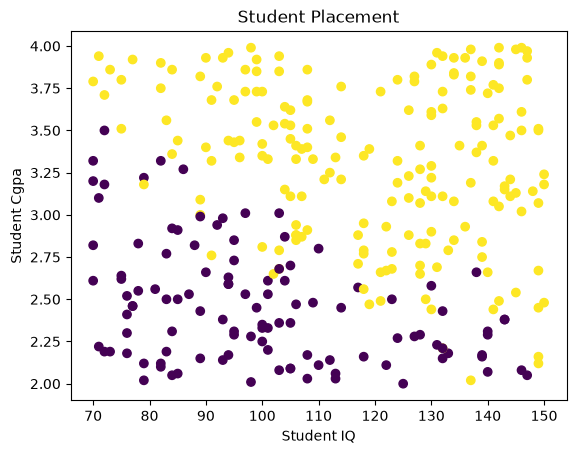

In [45]:
#plt.figure(figsize=(8 ,8))
plt.title("Student Placement")
plt.scatter(x, y, c=z)
plt.xlabel("Student IQ")
plt.ylabel("Student Cgpa")
plt.show()

In [46]:
X = data.iloc[::, :2:]
Y = data.iloc[::, -1]
print(X, "  ", Y)

      IQ  CGPA
0     84  2.05
1     98  2.28
2    139  2.17
3     73  2.19
4    147  2.05
..   ...   ...
295   82  3.75
296  137  3.82
297   88  2.82
298   89  2.15
299  103  2.68

[300 rows x 2 columns]    0      0
1      0
2      0
3      0
4      0
      ..
295    1
296    1
297    0
298    0
299    0
Name: placement, Length: 300, dtype: int64


In [47]:
x_train, x_test, y_train, y_test = skl.model_selection.train_test_split(X, Y, test_size=0.1)
scaler = skl.preprocessing.StandardScaler()

In [48]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [49]:
logisticRegression = skl.linear_model.LogisticRegression()
logisticRegression.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [50]:
predictions = logisticRegression.predict(x_test)
predictions

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 0])

In [51]:
y_test

210    1
176    1
127    1
15     1
299    0
164    1
36     1
151    1
216    1
170    1
248    1
274    1
85     1
179    0
54     0
262    1
146    0
290    1
291    0
165    0
38     1
37     1
70     1
195    0
51     1
247    0
102    0
59     0
13     1
208    0
Name: placement, dtype: int64

# Prediction From Different Data-Set

In [52]:
data_test = pd.read_csv("student_placement_test_dataset.csv")
data_test

,id,IQ,CGPA,placement
0,301,71,2.39,0
1,302,99,2.04,0
2,303,69,2.63,0
3,304,108,3.67,1
4,305,108,3.03,1
5,306,85,1.80,0
6,307,76,3.73,1
7,308,65,2.49,0
8,309,70,2.00,0
9,310,67,2.44,0


In [53]:
X_new_test = data_test.iloc[::, 1:3:]
Y_new_test = data_test.iloc[::, -1]

In [54]:
X_new_test = scaler.fit_transform(X_new_test)
X_new_test

array([[-1.22575848, -0.85987636],
       [-0.1976635 , -1.45563365],
       [-1.29919383, -0.45135707],
       [ 0.1327956 ,  1.31889316],
       [ 0.1327956 ,  0.2295084 ],
       [-0.71171099, -1.86415293],
       [-1.04217009,  1.42102299],
       [-1.44606455, -0.68965999],
       [-1.26247616, -1.52372019],
       [-1.37262919, -0.77476817],
       [ 0.7937138 , -0.87689799],
       [-0.01407511, -0.57050853],
       [-0.49140492,  1.21676334],
       [ 1.19760826,  1.16569843],
       [ 0.38981935,  1.4720879 ],
       [ 0.57340774,  0.70611424],
       [ 1.67493807,  0.3656815 ],
       [ 0.97730219,  0.63802769],
       [-1.29919383,  1.30187153],
       [-1.07888777,  1.55719608],
       [-0.67499331, -0.6045518 ],
       [-1.11560545,  0.84228733],
       [ 0.1327956 , -1.79606638],
       [ 1.49134968, -0.50242198],
       [-0.38125189, -0.34922725],
       [-1.1890408 ,  0.53589787],
       [ 1.49134968,  0.82526569],
       [-0.63827563, -1.28541728],
       [ 0.31638399,

In [55]:
new_prediction = logisticRegression.predict(X_new_test)
new_prediction

array([0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1])

## Evaluation Scores

Calculate the evaluation and prediction scores for both the old test split and the new test dataset.

In [56]:
#from sklearn.metrics import accuracy_score

old_evaluation_score = logisticRegression.score(x_test, y_test)
old_prediction_score = skl.metrics.accuracy_score(y_test, predictions)
new_evaluation_score = logisticRegression.score(X_new_test, Y_new_test)
new_prediction_score = skl.metrics.accuracy_score(Y_new_test, new_prediction)

print("Old evaluation score:", old_evaluation_score)
print("Old prediction score:", old_prediction_score)
print("New evaluation score:", new_evaluation_score)
print("New prediction score:", new_prediction_score)

Old evaluation score: 0.9333333333333333
Old prediction score: 0.9333333333333333
New evaluation score: 0.9166666666666666
New prediction score: 0.9166666666666666


<Axes: >

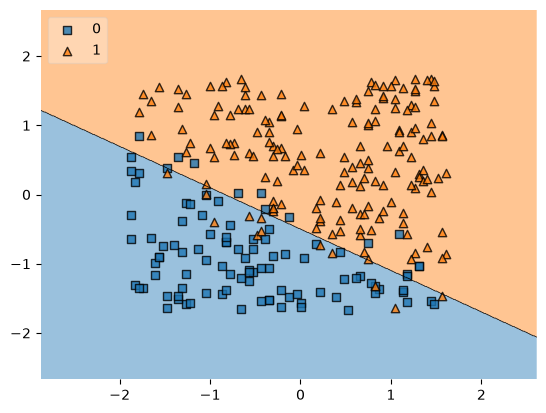

In [61]:
mlxp.plot_decision_regions(x_train, y_train.values, clf=logisticRegression, legend=2)

<Axes: >

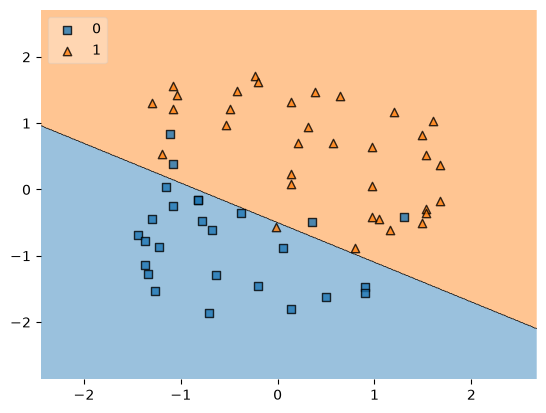

In [80]:
mlxp.plot_decision_regions(X_new_test, Y_new_test.values, clf=logisticRegression, legend=2)

In [ ]:
#import pickle as pkl
#pkl.dump(logisticRegression, open("model.pkl", "wb"))